<h1>Quick Start

In [2]:
import pandas as pd
import pickle

# --- 1) 댓글 단위 전처리 결과 ---
comments_df = pd.read_csv('preprocessed_comments.csv', encoding='utf-8-sig')

# --- 2) 영상 단위 집계 결과 ---
video_df = pd.read_csv('video_documents.csv', encoding='utf-8-sig')

# --- 3) TF-IDF 행렬 ---
with open('tfidf_matrix.pkl', 'rb') as f:
    tfidf_matrix = pickle.load(f)

# --- 4) TF-IDF Vectorizer ---
with open('tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

# --- 5) sentence BERT 행렬 ---
with open('sbert_matrix.pkl', 'rb') as f:
    sbert_matrix = pickle.load(f)

# === 로드 확인 ===
print('=== comments_df ===')
print(f'  Shape: {comments_df.shape}')
print(f'  Columns: {list(comments_df.columns)}')
print(comments_df.head(2))

print('\n=== video_df ===')
print(f'  Shape: {video_df.shape}')
print(f'  Columns: {list(video_df.columns)}')
print(video_df.head(2))

print(f'\n=== tfidf_matrix ===')
print(f'  Type: {type(tfidf_matrix)}')
print(f'  Shape: {tfidf_matrix.shape}')

print(f'\n=== vectorizer ===')
print(f'  Type: {type(vectorizer)}')
print(f'  Feature 수: {len(vectorizer.get_feature_names_out())}')
print(f'  Feature 샘플: {list(vectorizer.get_feature_names_out()[:10])}')

print(f'\n=== sbert_matrix ===')
print(f'  Type: {type(sbert_matrix)}')
print(f'  Shape: {sbert_matrix.shape}')

=== comments_df ===
  Shape: (9466, 8)
  Columns: ['Video Title', 'Video URL', 'Likes', 'Comment', 'category', 'Comment_clean', 'lang', 'tokens_clean']
                                         Video Title  \
0  NewJeans (뉴진스) 'OMG' Official MV (Performance ...   
1  NewJeans (뉴진스) 'OMG' Official MV (Performance ...   

                                           Video URL    Likes  \
0  https://www.youtube.com/watch?v=sVTy_wmn5SU&li...  2490682   
1  https://www.youtube.com/watch?v=sVTy_wmn5SU&li...  2490682   

                                             Comment category  \
0  민희진님은 절대 ㅈㅅ 안한다고 했습니다.\r\n️️️️️️️️️️\r\n이 댓글이 ...      뉴진스   
1  뉴진스 데뷔 미룬 것도 르세라핌이 5.2에 데뷔해야해서 그런거냐ㅜ방시혁 정신 좀 차...      뉴진스   

                                       Comment_clean lang  \
0  민희진님은 절대 안한다고 했습니다 이 댓글이 삭제된다면 하이브에서 삭제하는 것입니다...   ko   
1  뉴진스 데뷔 미룬 것도 르세라핌이 5 2에 데뷔해야해서 그런거냐 방시혁 정신 좀 차...   ko   

                         tokens_clean  
0  민희진 절대 댓글 삭제 하이브 삭제 좋다 누르다 위로 올려주다  
1   뉴진스 데뷔 미루다 세라핌 데뷔 그

c:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


<h1>K-Means 모델 학습

c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

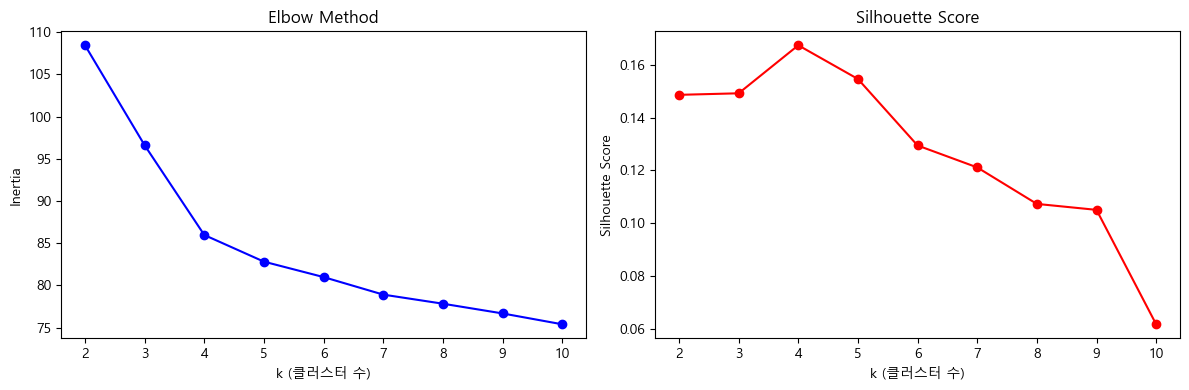

최적 k: 4
Silhouette Score: 0.1674
클러스터별 영상 수: [54 49 46 48]


c:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [3]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 윈도우 환경 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 그래프에서 마이너스(-) 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
with open('sbert_matrix.pkl', 'rb') as f:
    sbert_matrix = pickle.load(f)
video_df = pd.read_csv('video_documents.csv', encoding='utf-8-sig')

# --- Elbow Method + Silhouette Score ---
K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels=km.fit_predict(sbert_matrix)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(sbert_matrix, km.labels_))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k (클러스터 수)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, sil_scores, 'ro-')
axes[1].set_xlabel('k (클러스터 수)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.savefig('kmeans_optimal_k.png', dpi=150)
plt.show()

# 최적 k로 최종 모델 학습 (예: k=4)
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(sbert_matrix)

print(f'최적 k: {best_k}')
print(f'Silhouette Score: {silhouette_score(sbert_matrix, kmeans.labels_):.4f}')
print(f'클러스터별 영상 수: {np.bincount(kmeans.labels_)}')

<h1>PCA 2D 시각화로 클러스터 확인

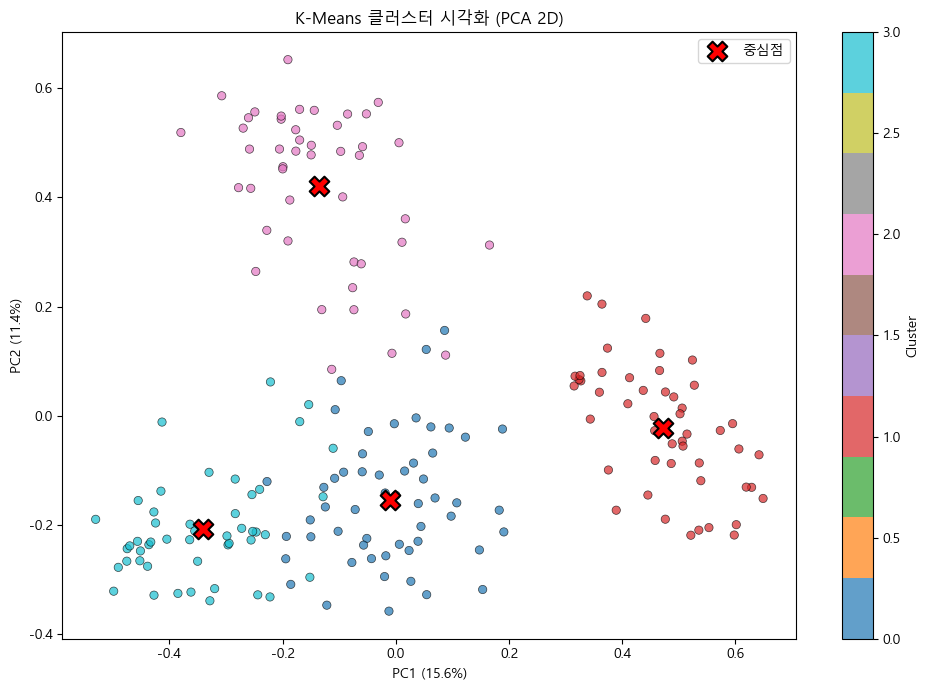


===== 클러스터 0 =====
- 영원하다 친구 영원하다 원수 재미있다 이해 쉬다 설명 해주다 구독 해보다 지도자 중요하다 가난하다 사다 이유 한나라 지도자 잘못 세우다 나라 망치다 순식간 구독 보다 가다 쏙쏙 친하다 원수 일도 이건 국가 에도 해당 궁굼 재미 자다 들다 읍니 종교인 정치 하니 선동 시키다 존나 쉬다 이미 가스 세뇌 시키다 만들다 보다 으로는 원수 로는 거래 국제 외교 기본 기본 이야 우리나라 사람 제일 이해 부분 이고 11분 30초 정리 해주다 감사하다 보다 중동 복잡 이스라엘 미국 과의 관계 궁금하다 영상 올리다 줄다 자다 정리 기사 이렇다 역사 헐다 누가 누구 필요 없넹 명괘 분석 음성 잘만 엇음 이란 이스라엘 관계 상세 알다 감사하다 보다 믿다 보다 이해 쏙쏙 좋다 구독 지역 틀리다 천년 싸우다 하물며 국가 에는 영원하다 친구 정정 혁명 일어나서 호메이니 지도자 이유 미국 싫다 어서 아니다 지도 부가 썩다 호화 스럽게 잔치 벌이 받다 터지다 미국 cia 보고서 정권 뒤지다 정도 아니다 정보 그냥 바로 전복 되어다 버리다 오랜 역사 가지다 페르시아 결국 이슬람 원리 주의 의하다 망가지다 서로 살리다 서로 죽이다 이란 이스라엘 싸우다 역사 이유 차다 아이러니 중동 매번 전쟁 일으키다 나라 얘기 자다 보고 듣다 가다 고맙다 영원하다 적도 영원하다 친구 진주만 습격 최초 원자폭탄 투하 미국 일본 동맹 더욱 급변 현재 국제 정세 각자 도생 자국 이익 국민 안전 절대 동맹 강하다 핵심 이유 일대일 분쇄 영상 보다 ai 만들다 영상 작다 음성 많이 거슬리다 설명 해주다 듣다 싶다 가끔 집중 안되다 국제사회 영원하다 적도 영원하다 친구 은혜 원수 갚다 서민 서민 생각 선동 당하다 말고 투표 자다 독재 국가 만들다 말고 차다 안타깝다 그러하다 역사 배경 새롭다 사실 되어다 감사하다 사람 잘못 통치 국민 힘들다 지다 ai 목소리 인가요 주머니 경제 목소리 똑같다 소리 가안 나오다 지도자 중요하다 우리 여기 판단 이란 미우다 아니다 이란 정권 미우다 

In [4]:
from sklearn.decomposition import PCA

# PCA로 2차원 축소
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(sbert_matrix)

# 시각화
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    coords[:, 0], coords[:, 1],
    c=kmeans.labels_, cmap='tab10', alpha=0.7, edgecolors='k', linewidths=0.5
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('K-Means 클러스터 시각화 (PCA 2D)')

# 클러스터 중심점 표시
centers_2d = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centers_2d[:, 0], centers_2d[:, 1],
    c='red', marker='X', s=200, edgecolors='k', linewidths=1.5, label='중심점'
)
plt.legend()
plt.tight_layout()
plt.savefig('kmeans_pca_visualization.png', dpi=150)
plt.show()

# 각 클러스터별 상위 키워드 확인
#with open('tfidf_vectorizer.pkl', 'rb') as f:
#    vectorizer = pickle.load(f)

#feature_names = vectorizer.get_feature_names_out()
# for i in range(best_k):
#     center = kmeans.cluster_centers_[i]
#     top_indices = center.argsort()[::-1][:10]
#     top_words = [feature_names[idx] for idx in top_indices]
#     print(f'클러스터 {i}: {", ".join(top_words)}')
video_df['cluster'] = labels

for i in range(best_k):
    print(f'\n===== 클러스터 {i} =====')
    cluster_data = video_df[video_df['cluster'] == i]

    for text in cluster_data['all_tokens'].head(10):
        print('-', text)

<h1>키워드 기반 클러스터 추천

In [5]:
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

import numpy as np

def recommend_by_cluster_sbert(keywords, top_n=5):
    """K-Means + Sentence-BERT 클러스터 기반 키워드 추천"""
    sbert_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')


    # 검색어 → Sentence-BERT 벡터 변환
    query_vec = sbert_model.encode(
        [keywords],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    # 클러스터 예측
    cluster_id = kmeans.predict(query_vec)[0]

    # 해당 클러스터 영상 인덱스 추출
    cluster_indices = np.where(kmeans.labels_ == cluster_id)[0]

    # 클러스터 내 cosine similarity 계산
    cluster_matrix = sbert_matrix[cluster_indices]
    similarities = cosine_similarity(query_vec, cluster_matrix).flatten()

    # 유사도 기준 정렬
    sorted_order = similarities.argsort()[::-1][:top_n]

    print(f'검색 키워드: "{keywords}"')
    print(f'할당된 클러스터: {cluster_id} (클러스터 내 영상 수: {len(cluster_indices)}개)\n')

    for rank, order_idx in enumerate(sorted_order, 1):
        video_idx = cluster_indices[order_idx]
        row = video_df.iloc[video_idx]

        print(f'{rank}. [{row["category"]}] {row["Video Title"]}')
        print(f'   유사도: {similarities[order_idx]:.4f} | 좋아요: {row["Likes"]:,} | 댓글: {row["comment_count"]}건')
        print(f'   URL: {row["Video URL"]}')
        print()

recommend_by_cluster_sbert('감동 응원 열정', top_n=5)
recommend_by_cluster_sbert('전쟁 평화 국제', top_n=3)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

검색 키워드: "감동 응원 열정"
할당된 클러스터: 0 (클러스터 내 영상 수: 54개)

1. [이스라엘] [UFC] 알렉스 페레이라 vs 이스라엘 아데산야
   유사도: 0.6590 | 좋아요: 36,118 | 댓글: 50건
   URL: https://www.youtube.com/watch?v=EwjeYVfTOgg&pp=ygUM7J207Iqk65287JeY

2. [월드컵] 드라마도 이렇게는 못 쓴다...😂 경우의 수보다 중요한 건 '꺾이지 않는 마음' [카타르월드컵 H조 대한민국 vs 포르투갈]
   유사도: 0.6457 | 좋아요: 28,975 | 댓글: 50건
   URL: https://www.youtube.com/watch?v=2iaiuOQM458&pp=ygUJ7JuU65Oc7Lu1

3. [월드컵] 월드컵을 가장한 롯데리아 컨설팅
   유사도: 0.5889 | 좋아요: 13,460 | 댓글: 50건
   URL: https://www.youtube.com/watch?v=fzSf6KaEw0s&pp=ygUJ7JuU65Oc7Lu1

4. [인공지능] “알파고가 10년 만의 대결을 청한 세계 바둑 1위” 신진서 9단의 상상 초월 훈련법, 적과의 공존 #사회 #EBS지식
   유사도: 0.5727 | 좋아요: 7,304 | 댓글: 50건
   URL: https://www.youtube.com/watch?v=UU8OjKQohVY&pp=ygUM7J246rO17KeA64ql

5. [월드컵] 한때 유행했던 음식 월드컵 (with 곽튜브, 키드밀리)
   유사도: 0.5580 | 좋아요: 7,865 | 댓글: 50건
   URL: https://www.youtube.com/watch?v=7kj4qqQXgYk&pp=ygUJ7JuU65Oc7Lu1



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

검색 키워드: "전쟁 평화 국제"
할당된 클러스터: 3 (클러스터 내 영상 수: 48개)

1. [이스라엘] [오늘 이 뉴스] "유태인 학살과 다를바 있나", 이스라엘 향해 李 '직설' (2026.04.10/MBC뉴스)
   유사도: 0.6704 | 좋아요: 19,267 | 댓글: 42건
   URL: https://www.youtube.com/watch?v=c0juaIczuGI&pp=ygUM7J207Iqk65287JeY

2. [이스라엘] '한국 대통령의 소신발언'..아랍권 매체들 '술렁' [뉴스.zip/MBC뉴스]
   유사도: 0.6615 | 좋아요: 21,190 | 댓글: 50건
   URL: https://www.youtube.com/watch?v=zBPQjBrwt5g&pp=ygUM7J207Iqk65287JeY

3. [이스라엘] 현시점 유럽까지 번지는 중이라는 미국·이스라엘-이란 전쟁 핵심만 요약해 봄 / 스브스뉴스
   유사도: 0.6579 | 좋아요: 10,945 | 댓글: 50건
   URL: https://www.youtube.com/watch?v=Zf8w7AP1Wxs&pp=ygUM7J207Iqk65287JeY



<h1>카테고리별 클러스터 분포 분석

=== 카테고리 × 클러스터 교차표 ===
cluster    0   1   2   3  All
category                     
뉴진스        0  49   1   0   50
월드컵       49   0   0   0   49
이스라엘       2   0   0  48   50
인공지능       3   0  45   0   48
All       54  49  46  48  197

=== 카테고리별 클러스터 비율 ===
cluster       0     1      2     3
category                          
뉴진스       0.000  0.98  0.020  0.00
월드컵       1.000  0.00  0.000  0.00
이스라엘      0.040  0.00  0.000  0.96
인공지능      0.062  0.00  0.938  0.00


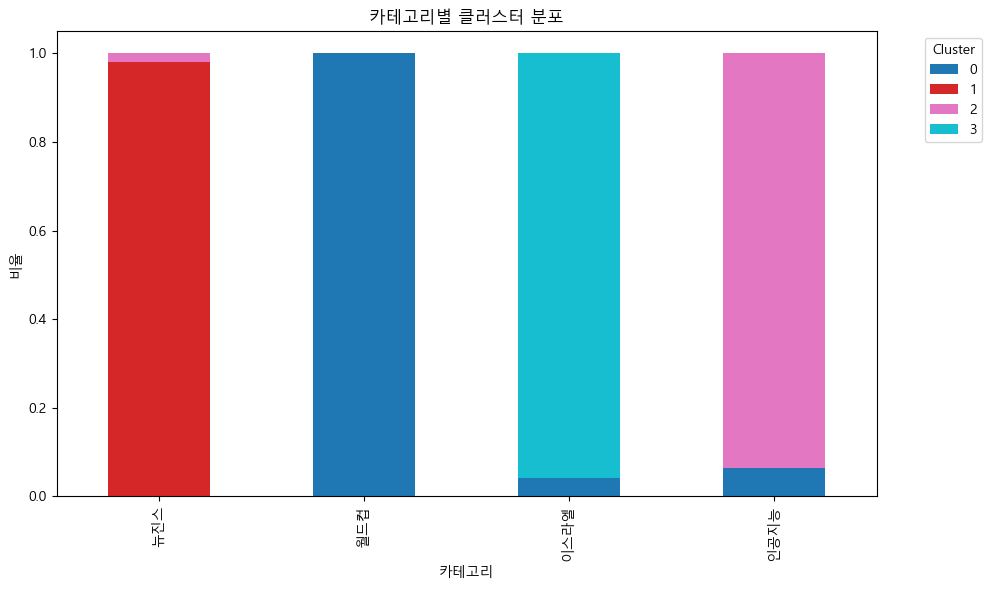

In [6]:
# 클러스터 레이블을 video_df에 추가
video_df['cluster'] = kmeans.labels_

# 교차표 생성
cross = pd.crosstab(video_df['category'], video_df['cluster'], margins=True)
print('=== 카테고리 × 클러스터 교차표 ===')
print(cross)

# 비율 교차표 (행 기준)
cross_pct = pd.crosstab(video_df['category'], video_df['cluster'], normalize='index')
print('\n=== 카테고리별 클러스터 비율 ===')
print(cross_pct.round(3))

# 시각화: 스택 바 차트
cross_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10')
plt.title('카테고리별 클러스터 분포')
plt.xlabel('카테고리')
plt.ylabel('비율')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('category_cluster_distribution.png', dpi=150)
plt.show()